# Model Analysis: ETF Cross-Asset Exposures

This notebook evaluates all predictive models trained on the ETF case study
and answers a single question: **which learned signals are real, stable,
and worth taking into a backtest?**

The ETF universe spans 100 instruments across equities, fixed income,
commodities, currencies, and real estate — a multi-asset cross-section
where the prediction problem is fundamentally different from single-stock
selection. Here the signal comes from relative macro exposures, not
firm-specific alpha. Momentum, carry, and volatility features dominate,
and the monthly rebalancing cadence (21-day forward return) means that
short-lived microstructure effects are irrelevant.

With 8 rolling-window folds (a fixed 10-year training window and a
1-year validation window each) spanning 2016–2023 in validation, plus a
2024–2025 holdout, this is one of the
most statistically complete case studies in the book. The challenge is
not sample size but signal strength: cross-sectional IC in diversified
ETFs is inherently modest because these instruments are already
diversified — there is less idiosyncratic variation to exploit.

**Learning Objectives**:
- Apply a structured model evaluation workflow to a real dataset
- Distinguish mean performance from fold-level stability
- Diagnose whether models learn different or redundant signals
- Use regime conditioning to understand when models work
- Make explicit, evidence-based decisions about which models to backtest

**Prerequisites**: Model training notebooks Ch11–15 must have run for this
case study. Linear and GBM results come from the registry; TabM, DL, and
latent factor results come from the training pipeline.

**Book Reference**: This notebook bridges Part III (Models, Ch11–15) and
Part IV (Strategy Implementation, Ch16–20). The chapter insights notebooks
in Ch11–15 compare each model family *across* case studies; here we compare
all families *within* a single dataset.

In [1]:
"""Model Analysis: ETFs — comparative evaluation across all model families."""

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import yaml

from case_studies.utils.latent_factors import load_fold_extras
from case_studies.utils.model_analysis import (
    best_model_per_family_fast,
    fold_performance_matrix,
    load_all_metrics,
    load_gbm_feature_importance,
    load_predictions,
    prediction_bucket_monotonicity,
    prediction_correlation_matrix,
    regime_conditional_ic,
)
from case_studies.utils.model_viz import (
    plot_bucket_monotonicity,
    plot_correlation_matrix,
    plot_cv_timeline,
    plot_feature_importance_heatmap,
    plot_fold_boxplot,
    plot_fold_heatmap,
    plot_label_horizon_forest,
    plot_learning_curves,
    plot_regime_bars,
)
from case_studies.utils.notebook_render import (
    conformal_coverage_diagnostic,
    fold_heatmap_with_ci,
    headline_forest_plot,
    holdout_decay_table,
    selection_adjusted_leader_table,
)
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY = "etfs"
PRIMARY_LABEL = "fwd_ret_21d"
DATE_COL = "timestamp"
ENTITY_COL = "symbol"
N_BUCKETS = 10
TOP_N_FEATURES = 15
REGIME_WINDOW = 63

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

n_splits = setup["evaluation"]["n_splits"]
train_size = setup["evaluation"]["train_size"]
val_size = setup["evaluation"]["val_size"]
holdout_start = setup["evaluation"].get("holdout_start")
n_assets = setup["universe"]["n_assets"]
costs = setup["costs"]
per_share_usd = costs["per_share"]
default_half_spread_usd = costs["default_half_spread_usd"]

# ETFs use per_share + half-spread (not bps). Provide a representative bps
# range for the bucket-monotonicity overlay so readers can compare
# bucket-spread magnitudes against typical ETF round-trip frictions.
# 5 bps anchors mega-cap liquid ETFs (SPY/QQQ/IWM); 15 bps anchors sector
# and country funds. See setup.yaml.costs for per-asset half-spreads.
cost_range = [5, 15]

print(f"Case Study: {CASE_STUDY}")
print(f"  Universe: {n_assets} ETFs (equities, bonds, commodities, FX, sectors)")
print(f"  Label: {PRIMARY_LABEL} (monthly rebalancing)")
print(f"  CV: {n_splits} rolling-window folds, train={train_size}, val={val_size}")
print(f"  Holdout: {holdout_start} onwards")
print(
    f"  Trading costs: ${per_share_usd:.4f}/share + tiered half-spread "
    f"(mega 0.5¢, sector 1¢, default {default_half_spread_usd * 100:.0f}¢)"
)

Case Study: etfs
  Universe: 100 ETFs (equities, bonds, commodities, FX, sectors)
  Label: fwd_ret_21d (monthly rebalancing)
  CV: 8 rolling-window folds, train=10Y, val=1Y
  Holdout: 2024-01-01 onwards
  Trading costs: $0.0035/share + tiered half-spread (mega 0.5¢, sector 1¢, default 2¢)


## 1. What Is the Prediction Problem?

**Primary target tuple**: `fwd_ret_21d` | regression | IC | monthly rebalancing

We predict the 21-trading-day forward return for each of 100 ETFs,
ranking them cross-sectionally at each month-end to identify the
highest-expected-return instruments. The strategy buys the top-ranked
ETFs and rebalances monthly.

**Panel shape**: $T \approx 5{,}000$ daily observations (2006–2025),
$N = 100$ ETFs, evaluated at the monthly rebalancing cadence (so
$T_{\text{month}} \approx 240$). The cross-section is sparse relative
to the time dimension, but well-suited to latent factor methods because
the asset categories (equity sectors, bonds, commodities, currencies)
provide an economically meaningful low-rank prior. ETFs is one of the
five case studies in scope for the Ch14 latent-factor pipeline.

The feature set (57 features) emphasizes momentum at multiple horizons
(5d to 252d), risk-adjusted momentum (Sharpe ratios), volatility
regimes, technical indicators, and macro signals (yield curve slope).
There are no fundamental or alternative data features — the signal
is purely price-derived.

The universe mixes asset classes deliberately: sector equity ETFs
(XLK, XLE), country ETFs (EWJ, EWZ), bond ETFs (TLT, HYG),
commodity ETFs (GLD, USO), and currency ETFs (FXE, UUP). This
cross-asset structure means the model must learn which macro
exposures are currently rewarded, not which individual stocks
are mispriced.

In [4]:
# Phase 1: Load pre-computed metrics for ALL labels (coverage + multi-label analysis)
all_labels_metrics = load_all_metrics(CASE_STUDY, label=None).filter(pl.col("label").is_not_null())
all_metrics = all_labels_metrics.filter(pl.col("label") == PRIMARY_LABEL)

if all_metrics.height == 0:
    raise RuntimeError(f"No metrics found for {CASE_STUDY} / {PRIMARY_LABEL}")

families_present = sorted(all_metrics["family"].unique().to_list())
print(f"Pre-computed metrics: {all_metrics.height} entries across {len(families_present)} families")

for fam in families_present:
    sub = all_metrics.filter(pl.col("family") == fam)
    configs = sub["config_name"].n_unique()
    checkpoints = sub["checkpoint_value"].drop_nulls().n_unique()
    best_ic = sub["ic_mean"].max()
    best_ic_text = f"{best_ic:+.4f}" if best_ic is not None else "n/a"
    print(
        f"  {fam:20s}  {configs:3d} configs  {checkpoints:3d} checkpoints  best IC={best_ic_text}"
    )

# Coverage completeness check
EXPECTED_FAMILIES = {"linear", "gbm", "tabular_dl", "deep_learning", "latent_factors", "causal_dml"}
missing = EXPECTED_FAMILIES - set(families_present)
if missing:
    n_present = len(families_present)
    print(
        f"\nCOVERAGE: {n_present}/6 model families present. Missing: {', '.join(sorted(missing))}"
    )
    print("  Recommendations below may change when missing families are added.")
else:
    print("\nFull coverage: all 6 model families present.")

Pre-computed metrics: 104 entries across 5 families
  deep_learning           3 configs    5 checkpoints  best IC=+0.0622
  gbm                    15 configs    0 checkpoints  best IC=+0.0440
  latent_factors          5 configs   19 checkpoints  best IC=+0.0944
  linear                 27 configs    0 checkpoints  best IC=+0.0420
  tabular_dl              3 configs    8 checkpoints  best IC=+0.0341

COVERAGE: 5/6 model families present. Missing: causal_dml
  Recommendations below may change when missing families are added.


In [5]:
# Best model per family
best_per_family = best_model_per_family_fast(all_metrics)

print("\nBest model per family:")
print(best_per_family.select(["family", "config_name", "checkpoint_value", "ic_mean", "ic_std"]))


Best model per family:
shape: (5, 5)
┌────────────────┬──────────────────┬──────────────────┬──────────┬──────────┐
│ family         ┆ config_name      ┆ checkpoint_value ┆ ic_mean  ┆ ic_std   │
│ ---            ┆ ---              ┆ ---              ┆ ---      ┆ ---      │
│ str            ┆ str              ┆ i64              ┆ f64      ┆ f64      │
╞════════════════╪══════════════════╪══════════════════╪══════════╪══════════╡
│ latent_factors ┆ sdf              ┆ 0                ┆ 0.094425 ┆ 0.058001 │
│ deep_learning  ┆ nlinear          ┆ 55               ┆ 0.062197 ┆ 0.05648  │
│ gbm            ┆ leaves_7_mae     ┆ null             ┆ 0.043997 ┆ 0.06852  │
│ linear         ┆ ridge_a1000000.0 ┆ null             ┆ 0.042013 ┆ 0.039537 │
│ tabular_dl     ┆ tabm_l           ┆ 125              ┆ 0.034087 ┆ 0.042442 │
└────────────────┴──────────────────┴──────────────────┴──────────┴──────────┘


In [6]:
# Phase 2: Load raw predictions ONLY for the ~5 best models (not all 47M+)
representative_preds = []

for row in best_per_family.filter(pl.col("family") != "causal_dml").iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    preds = load_predictions(
        CASE_STUDY,
        family=family,
        label=PRIMARY_LABEL,
        config_name=config,
        checkpoint_value=checkpoint,
    )
    if preds.height > 0:
        representative_preds.append(preds)
        print(f"  Loaded {family}/{config}: {preds.height:,} predictions")

if representative_preds:
    best_preds = pl.concat(representative_preds, how="diagonal_relaxed")
    # Normalize DATE_COL to Datetime (parquets may store as Date or String)
    if best_preds.height > 0 and best_preds[DATE_COL].dtype == pl.String:
        best_preds = best_preds.with_columns(pl.col(DATE_COL).str.to_datetime())
    elif best_preds.height > 0 and best_preds[DATE_COL].dtype == pl.Date:
        best_preds = best_preds.with_columns(pl.col(DATE_COL).cast(pl.Datetime("ms")))
    print(f"\nTotal representative predictions: {best_preds.height:,}")
else:
    best_preds = pl.DataFrame()
    print("WARNING: No raw predictions could be loaded")

  Loaded latent_factors/sdf: 190,234 predictions
  Loaded deep_learning/nlinear: 189,754 predictions
  Loaded gbm/leaves_7_mae: 190,234 predictions
  Loaded linear/ridge_a1000000.0: 190,234 predictions
  Loaded tabular_dl/tabm_l: 190,234 predictions

Total representative predictions: 950,690


In [7]:
# Fold date ranges for timeline
if best_preds.height > 0:
    fold_ranges = (
        best_preds.filter(pl.col("fold_id").is_not_null())
        .group_by("fold_id")
        .agg(
            pl.col(DATE_COL).min().cast(pl.Date).alias("val_start"),
            pl.col(DATE_COL).max().cast(pl.Date).alias("val_end"),
        )
        .sort("fold_id")
    )

### Figure 1: Cross-Validation Timeline

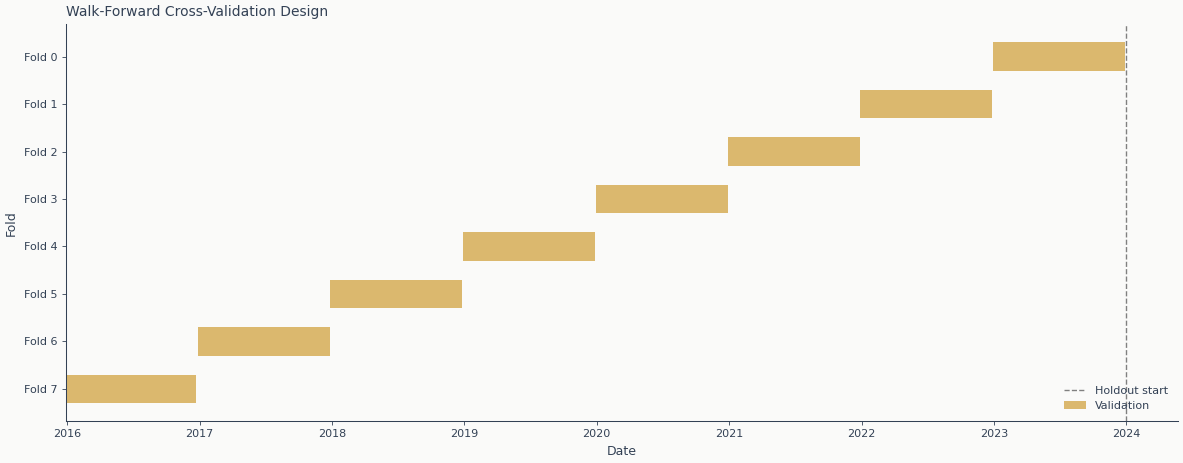

In [8]:
if best_preds.height > 0 and fold_ranges.height > 0:
    plot_cv_timeline(fold_ranges, n_splits, holdout_start)

Each fold trains on a fixed 10-year rolling window and validates on the
year that follows it. The folds are numbered in reverse-chronological
order: fold 0 validates the most recent pre-holdout year (2023) and
fold 7 the earliest (2016), with the 10-year training window sliding
back accordingly. The holdout period (2024 onwards) is never used for
model selection.

Because the window is a fixed 10 years rather than expanding, every fold
sees the same amount of training data; what differs across folds is the
market regime each validation year falls in (the 2020 COVID shock, the
2022 rate shock). A model that works only in a handful of folds may be
learning regime-specific patterns rather than persistent structure.

## 2. What Was Actually Run?

Before comparing results, we map what is actually comparable. Not all
model families were trained on all labels, and the five modeling
chapters contribute different kinds of evidence: Ch11–13 produce
predictive forecasts; Ch14 extracts latent structure; Ch15 estimates
causal effects. Forcing all of these into a single ranking would be
misleading.

In [9]:
# Coverage map: family × label × evidence type
EVIDENCE_TYPE = {
    "linear": "predictive",
    "gbm": "predictive",
    "tabular_dl": "predictive",
    "deep_learning": "predictive",
    "latent_factors": "structural",
    "causal_dml": "causal",
}
FAMILY_CHAPTER = {
    "linear": "Ch11",
    "gbm": "Ch12",
    "tabular_dl": "Ch12",
    "deep_learning": "Ch13",
    "latent_factors": "Ch14",
    "causal_dml": "Ch15",
}

coverage = (
    all_labels_metrics.group_by(["family", "label"])
    .agg(
        pl.col("config_name").n_unique().alias("n_configs"),
        pl.col("ic_mean").max().alias("best_ic"),
    )
    .with_columns(
        chapter=pl.col("family").replace(FAMILY_CHAPTER),
        evidence=pl.col("family").replace(EVIDENCE_TYPE),
    )
    .sort(["family", "label"])
)

print("Coverage Map: Families × Labels")
print(coverage.select(["chapter", "family", "label", "evidence", "n_configs", "best_ic"]))

Coverage Map: Families × Labels
shape: (8, 6)
┌─────────┬────────────────┬─────────────┬────────────┬───────────┬──────────┐
│ chapter ┆ family         ┆ label       ┆ evidence   ┆ n_configs ┆ best_ic  │
│ ---     ┆ ---            ┆ ---         ┆ ---        ┆ ---       ┆ ---      │
│ str     ┆ str            ┆ str         ┆ str        ┆ u32       ┆ f64      │
╞═════════╪════════════════╪═════════════╪════════════╪═══════════╪══════════╡
│ Ch13    ┆ deep_learning  ┆ fwd_ret_21d ┆ predictive ┆ 3         ┆ 0.062197 │
│ Ch12    ┆ gbm            ┆ fwd_ret_21d ┆ predictive ┆ 15        ┆ 0.043997 │
│ Ch12    ┆ gbm            ┆ fwd_ret_5d  ┆ predictive ┆ 15        ┆ 0.029909 │
│ Ch14    ┆ latent_factors ┆ fwd_ret_21d ┆ structural ┆ 5         ┆ 0.094425 │
│ Ch14    ┆ latent_factors ┆ fwd_ret_5d  ┆ structural ┆ 2         ┆ 0.024162 │
│ Ch11    ┆ linear         ┆ fwd_ret_21d ┆ predictive ┆ 27        ┆ 0.042013 │
│ Ch11    ┆ linear         ┆ fwd_ret_5d  ┆ predictive ┆ 24        ┆ 0.029938 │
│ Ch12

In [10]:
# Primary label coverage summary
primary_coverage = coverage.filter(pl.col("label") == PRIMARY_LABEL)
predictive_families = primary_coverage.filter(pl.col("evidence") == "predictive")[
    "family"
].to_list()
structural_families = primary_coverage.filter(pl.col("evidence") == "structural")[
    "family"
].to_list()
causal_families = primary_coverage.filter(pl.col("evidence") == "causal")["family"].to_list()
all_labels = sorted(coverage["label"].unique().to_list())

print(f"\nPrimary label ({PRIMARY_LABEL}):")
print(f"  Predictive families: {predictive_families}")
print(f"  Structural families: {structural_families or 'none'}")
print(f"  Causal families: {causal_families or 'none'}")
print(f"\nAll labels trained: {all_labels}")


Primary label (fwd_ret_21d):
  Predictive families: ['deep_learning', 'gbm', 'linear', 'tabular_dl']
  Structural families: ['latent_factors']
  Causal families: none

All labels trained: ['fwd_ret_21d', 'fwd_ret_5d']


The ETF case study has five predictive/structural model families on the
primary label (`fwd_ret_21d`), spanning four of the five modeling chapters
(Ch11–14); causal DML (Ch15) is evaluated separately as causal evidence in
Section 7, not as a predictive family here.
Notably, latent factor models (Ch14) were trained despite the
relatively narrow 100-ETF cross-section. The validation daily-pooled
IC ordering (highest-IC full-coverage config per family) places latent
factors first via SDF at IC +0.099, deep learning second via NLinear
at +0.062, GBM third via the 7-leaf MAE tree at +0.044, linear fourth
via ridge ($\alpha=10^6$) at +0.042, and tabular DL fifth via TabM-L
at +0.034. Within latent factors, the highest-IC estimator is SDF, at
IC +0.099 ($t_{HAC}=5.7$) — the strongest single signal in the whole
comparison; SAE follows at +0.064 ($t_{HAC}=3.3$) and CAE at +0.046
($t_{HAC}=2.1$) also clears zero, while PCA and IPCA do not — three of
the five LF estimators show credible signal on this panel.

Two labels were explored: the primary `fwd_ret_21d` (monthly) and
`fwd_ret_5d` (weekly). The shorter horizon has narrower family
coverage; all cross-family comparisons in this notebook use the
primary label unless stated otherwise.

## 3. Headline Comparative View

Before comparing model families, we establish a baseline. If the
simplest possible model — OLS linear regression on 57 momentum and
volatility features — produces zero or negative IC, the prediction
problem is fundamentally too hard for this cross-section.

In [11]:
# Linear baseline
linear_metrics = all_metrics.filter(pl.col("family") == "linear")
if linear_metrics.height > 0:
    for name in ["ols", "ridge_a0.001", "ridge_a0.01", "ridge"]:
        baseline = linear_metrics.filter(pl.col("config_name") == name)
        if baseline.height > 0:
            ic = baseline["ic_mean"][0]
            std = baseline["ic_std"][0] if baseline["ic_std"][0] is not None else 0
            print(f"Linear baseline ({name}):")
            print(f"  IC mean:  {ic:+.4f}" if ic is not None else "  IC mean:  n/a")
            if std > 0:
                print(f"  IC std:   {std:.4f}")
                t_stat = (ic if ic is not None else 0) / (std / np.sqrt(n_splits))
                print(f"  t-stat:   {t_stat:.1f} (across {n_splits} folds)")
            break

Linear baseline (ols):
  IC mean:  +0.0269
  IC std:   0.0740
  t-stat:   1.0 (across 8 folds)


In [12]:
# Headline forest — per-family highest daily-pooled IC config with HAC 95% CI,
# drawn from the already-loaded validation metrics (ic_mean_daily, ic_ci_lo,
# ic_ci_hi, ic_t_hac). Restrict to full-coverage configs: a config that
# degenerates to constant predictions on some folds (e.g. a high-L1 ElasticNet
# whose coefficients all shrink to zero) has undefined daily IC on those folds
# and a partial ic_n_days, and must not be shown as a family's leader on a
# subset-of-folds IC. This matches best_per_family below.
_full_days = all_metrics["ic_n_days"].max()
forest_df = (
    all_metrics.filter(
        pl.col("ic_mean_daily").is_not_null(),
        pl.col("ic_n_days") == _full_days,
    )
    .sort("ic_mean_daily", descending=True, nulls_last=True)
    .group_by("family")
    .first()
    .sort("ic_mean_daily", descending=True, nulls_last=True)
    .select(
        "family",
        "config_name",
        "ic_mean_daily",
        "ic_ci_lo",
        "ic_ci_hi",
        "ic_t_hac",
        "ic_n_days",
    )
)
print("Validation IC with HAC 95% CI (highest-IC config per family):")
print(
    forest_df.select(
        "family",
        "config_name",
        pl.col("ic_mean_daily").round(4).alias("ic"),
        pl.col("ic_ci_lo").round(4).alias("ci_lo"),
        pl.col("ic_ci_hi").round(4).alias("ci_hi"),
        pl.col("ic_t_hac").round(2).alias("t_hac"),
        pl.col("ic_n_days").cast(pl.Int64).alias("n_days"),
    )
)

Validation IC with HAC 95% CI (highest-IC config per family):
shape: (5, 7)
┌────────────────┬──────────────────┬────────┬─────────┬────────┬───────┬────────┐
│ family         ┆ config_name      ┆ ic     ┆ ci_lo   ┆ ci_hi  ┆ t_hac ┆ n_days │
│ ---            ┆ ---              ┆ ---    ┆ ---     ┆ ---    ┆ ---   ┆ ---    │
│ str            ┆ str              ┆ f64    ┆ f64     ┆ f64    ┆ f64   ┆ i64    │
╞════════════════╪══════════════════╪════════╪═════════╪════════╪═══════╪════════╡
│ latent_factors ┆ sdf              ┆ 0.0992 ┆ 0.0651  ┆ 0.1333 ┆ 5.71  ┆ 2016   │
│ deep_learning  ┆ nlinear          ┆ 0.0622 ┆ 0.0219  ┆ 0.1025 ┆ 3.02  ┆ 2016   │
│ gbm            ┆ leaves_7_mae     ┆ 0.044  ┆ 0.0061  ┆ 0.0819 ┆ 2.28  ┆ 2016   │
│ linear         ┆ ridge_a1000000.0 ┆ 0.042  ┆ -0.0034 ┆ 0.0874 ┆ 1.82  ┆ 2016   │
│ tabular_dl     ┆ tabm_l           ┆ 0.0341 ┆ -0.0003 ┆ 0.0685 ┆ 1.94  ┆ 2016   │
└────────────────┴──────────────────┴────────┴─────────┴────────┴───────┴────────┘


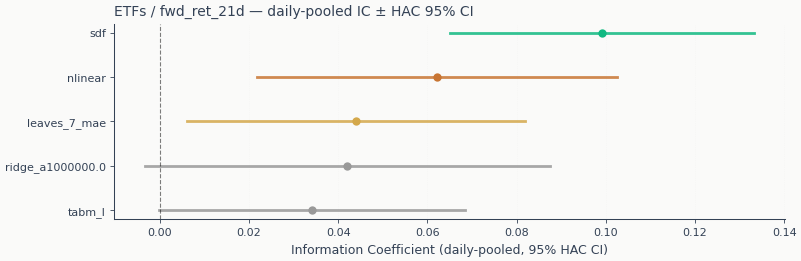

In [13]:
forest_fig = headline_forest_plot(
    forest_df,
    ic_col="ic_mean_daily",
    ci_lo_col="ic_ci_lo",
    ci_hi_col="ic_ci_hi",
    label_col="config_name",
    family_col="family",
    title=f"ETFs / {PRIMARY_LABEL} — daily-pooled IC ± HAC 95% CI",
)
forest_fig.show()

**Signal present but uncertainty matters.** Reading the forest plot rather
than a point-estimate ranking changes the story. Per-family highest-IC CIs
overlap heavily, and the HAC-corrected confidence intervals are wide
enough that small IC differences are not statistically separable. The
numbers cited below come from the validation block printed above.

What the figure does support:

- The clear leader is the latent-factor family via SDF at IC $\approx$
  0.099, with a HAC CI whose lower bound clears zero by a wide margin
  (lower bound $\approx$ 0.065; $t_{HAC} \approx 5.7$). It is the only
  family that separates cleanly from the pack rather than overlapping
  with its neighbors — the strongest single piece of evidence for
  cross-sectional predictability on the panel.
- Deep learning (NLinear) is the runner-up at IC $\approx$ 0.062 with a
  CI lower bound $\approx$ 0.022 ($t_{HAC} \approx 3.0$) — the strongest
  non-latent signal, credibly nonzero but well below SDF.
- GBM (7-leaf MAE tree) at IC $\approx$ 0.044 has a CI whose lower bound
  just clears zero ($\approx$ 0.006; $t_{HAC} \approx 2.3$) — marginal
  but credibly positive.
- The high-regularization linear leader (ridge with $\alpha=10^6$) at
  IC $\approx$ 0.042 has a CI that straddles zero
  ($\approx [-0.003, 0.087]$; $t_{HAC} \approx 1.8$): directionally
  positive but not statistically distinguishable from no signal at the
  95% level. Even the strongest linear configuration does not clear the
  HAC bar on this panel.
- Tabular DL (TabM-L) at IC $\approx$ 0.034 sits at the bottom with a CI
  lower bound essentially at zero ($\approx -0.000$; $t_{HAC} \approx
  1.9$) — a borderline signal.
- The OLS baseline (no regularization) anchors the comparison at IC
  $\approx$ 0.027 (CI straddles zero, $t_{HAC} \approx 1.4$): signal is
  directionally present but weak, and regularization lifts the linear
  family only modestly above it.

Reading the plot, the substantive ordering is "one dominant (SDF), one
clear (NLinear), one marginal (GBM), two borderline (linear, tabular)."
SDF aside, the remaining families sit on a continuum of uncertainty with
heavily overlapping CIs, so distinctions *below* the leader should not be
over-read. The next sections examine fold-level stability (Section 4),
what the models learn (Section 5), and the cost of having tried many
configs before declaring a highest-IC config (Section 8).

### Which Model Families Extract the Most Signal?

The primary comparison uses the best configuration from each family,
evaluated not just by mean IC but by consistency across 8 folds.
A model with the highest average IC is not the most credible choice
if that average is carried by one or two exceptional windows.

In [14]:
# Build fold × family IC matrix from raw predictions
fold_ic = (
    fold_performance_matrix(best_preds, date_col=DATE_COL)
    if best_preds.height > 0
    else pl.DataFrame()
)

### Figure 2: Fold-by-Model Performance Heatmap

Cells where the within-fold IC is not credibly nonzero (two-sided
normal-approx $p > 0.05$ from $|\text{IC}| / (\text{ic\_std}/\sqrt{N})$)
are rendered in muted gray. The signal that survives this gate is
concentrated in folds and families where IC is large relative to
its within-fold dispersion — not just folds where the *mean* IC
happens to be high.

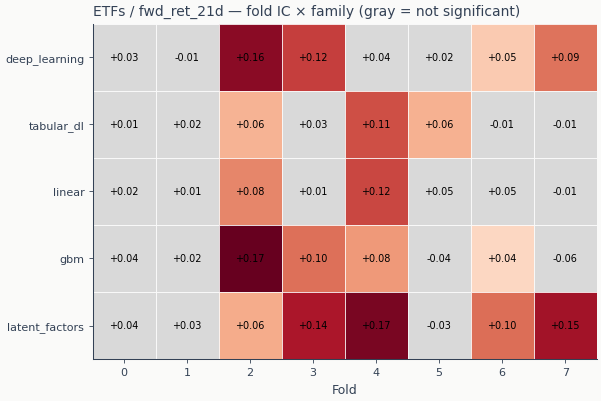

In [15]:
fold_heatmap_fig = fold_heatmap_with_ci(
    CASE_STUDY,
    label=PRIMARY_LABEL,
    title=f"ETFs / {PRIMARY_LABEL} — fold IC × family (gray = not significant)",
)
fold_heatmap_fig.show()

In [16]:
# Summary statistics per family
if fold_ic.height > 0:
    family_stats = (
        fold_ic.group_by("model_label")
        .agg(
            pl.col("ic_mean").mean().alias("mean_ic"),
            pl.col("ic_mean").median().alias("median_ic"),
            pl.col("ic_mean").std().alias("std_ic"),
            pl.col("ic_mean").min().alias("worst_fold"),
            pl.col("ic_mean").max().alias("best_fold"),
            (pl.col("ic_mean") > 0).mean().alias("pct_positive"),
            pl.col("ic_mean").count().alias("n_folds"),
        )
        .sort("mean_ic", descending=True)
    )
    print("Family performance summary:")
    print(family_stats)

Family performance summary:
shape: (5, 8)
┌──────────────┬──────────┬───────────┬──────────┬────────────┬───────────┬──────────────┬─────────┐
│ model_label  ┆ mean_ic  ┆ median_ic ┆ std_ic   ┆ worst_fold ┆ best_fold ┆ pct_positive ┆ n_folds │
│ ---          ┆ ---      ┆ ---       ┆ ---      ┆ ---        ┆ ---       ┆ ---          ┆ ---     │
│ str          ┆ f64      ┆ f64       ┆ f64      ┆ f64        ┆ f64       ┆ f64          ┆ u32     │
╞══════════════╪══════════╪═══════════╪══════════╪════════════╪═══════════╪══════════════╪═════════╡
│ latent_facto ┆ 0.071852 ┆ 0.075251  ┆ 0.062005 ┆ 0.008515   ┆ 0.164521  ┆ 1.0          ┆ 8       │
│ rs/sdf       ┆          ┆           ┆          ┆            ┆           ┆              ┆         │
│ deep_learnin ┆ 0.062197 ┆ 0.042912  ┆ 0.05648  ┆ -0.011418  ┆ 0.157405  ┆ 0.875        ┆ 8       │
│ g/nlinear    ┆          ┆           ┆          ┆            ┆           ┆              ┆         │
│ gbm/leaves_7 ┆ 0.043997 ┆ 0.037805  ┆ 0.073251 

The heatmap reveals several patterns specific to the ETF cross-section:

- **Latent factors (SDF)** leads decisively with IC +0.099 and the
  strongest HAC t-statistic in the whole comparison ($t_{HAC} \approx
  5.7$). SAE follows within the same family at IC +0.064
  ($t_{HAC} \approx 3.3$) — SDF's pricing-kernel objective is the
  clearest evidence of factor structure on this panel.
- **Deep learning (NLinear)** is the runner-up at IC +0.062
  ($t_{HAC} \approx 3.0$), the strongest non-latent signal. The compact
  NLinear architecture matches the cross-sectional ranking task without
  the temporal-overfitting risk that the LSTM-class configurations show
  on a 100-ETF panel.
- **GBM** (7-leaf MAE tree) comes third at IC +0.044 with a CI whose
  lower bound just clears zero ($t_{HAC} \approx 2.3$) — the tree
  ensemble extracts a marginal but credible signal here.
- **Linear (ridge, $\alpha=10^6$)** is fourth at IC +0.042 with a CI
  that straddles zero ($t_{HAC} \approx 1.8$). Heavy shrinkage near the
  prior captures the bulk of the linear-in-features signal, and
  lower-$\alpha$ ridge configurations cluster within $\approx$ 0.005 IC
  of each other (see the per-config table in Section 3) — but even the
  best linear config is not statistically separable from zero.
- **TabM-L** achieves IC +0.034, positive in most folds though with a
  notable negative fold — likely a period where momentum reversal
  dominated (e.g., the post-COVID rotation). Its CI lower bound sits
  essentially at zero.
- **Among latent-factor estimators**, SDF, SAE, and (marginally) CAE
  deliver credibly nonzero IC at their highest config ($t_{HAC}$ of 5.7,
  3.3, and 2.1); PCA and IPCA have CIs that straddle zero. PCA in
  particular ($t_{HAC} \approx 0.4$) does not serve as the trustworthy
  linear-LF baseline some of the other case studies provide.

## 4. Stability Over Time

Mean IC can be misleading when carried by a few strong folds.
For a monthly rebalancing strategy running over years, the
consistency of signal matters more than peak performance.
A model that delivers IC = 0.03 in every fold is a better
foundation than one that delivers IC = 0.10 in two folds
and IC = −0.05 in six.

### Figure 3: Fold Performance Distribution by Model Family

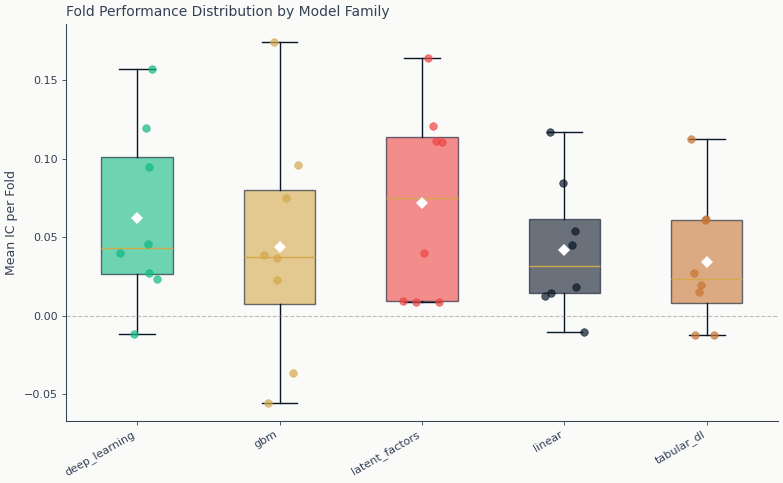

In [17]:
plot_fold_boxplot(fold_ic)

The box plots show that SDF is both the highest and the *steadiest*
family: it is positive in all 8 folds (worst fold +0.009) and carries the
highest median IC. Among the others, ridge regression is the *safest* —
its interquartile range is the tightest (fold std $\approx$ 0.04) and its
worst fold is only slightly negative — though its mean is modest. GBM
shows the widest tails (fold std $\approx$ 0.07, worst fold $\approx
-0.055$): a high-variance family whose average is carried by its strong
folds. NLinear is positive in 7 of 8 folds but with a wide spread — the
temporal inductive bias of sequence models helps when it aligns with the
cross-sectional ranking and hurts when it does not.

For a reader designing a live strategy, the practical lesson is clear:
**a model's worst fold matters more than its best fold**, because you
will inevitably deploy through unfavorable regimes.

## 5. What Are the Models Learning?

Beyond aggregate IC, we examine the *structure* of predictions. Two
diagnostic questions matter:

1. **Monotonicity**: do higher predicted scores correspond to higher
   realized returns? A monotonic relationship confirms ranking ability.
2. **Diversity**: do different model families produce similar or
   different rankings? Low correlation between families means ensemble
   value; high correlation means diminishing returns from complexity.

In [18]:
# Compute prediction bucket monotonicity for best model per family
bucket_results = {}
for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    buckets = prediction_bucket_monotonicity(model_preds, N_BUCKETS, DATE_COL)
    if buckets.height > 0:
        bucket_results[family] = buckets

### Figure 4: Prediction Bucket Monotonicity


Top-bottom bucket spread vs trading costs (5–15 bps per leg):
  latent_factors        spread=+57 bps  edge/cost=5.7–1.9x
  deep_learning         spread=+80 bps  edge/cost=8.0–2.7x
  gbm                   spread=+53 bps  edge/cost=5.3–1.8x
  linear                spread=+60 bps  edge/cost=6.0–2.0x
  tabular_dl            spread=+32 bps  edge/cost=3.2–1.1x


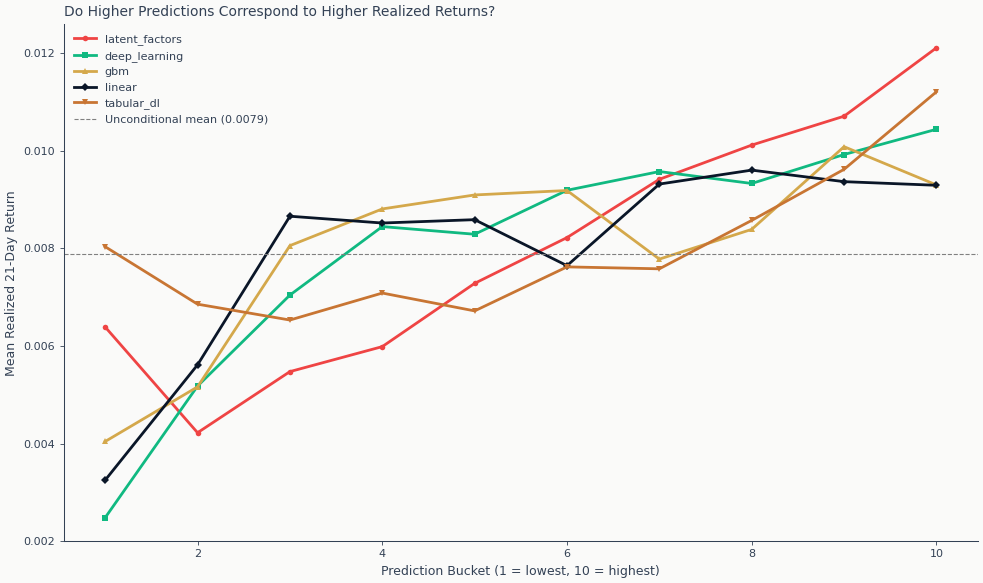

In [19]:
plot_bucket_monotonicity(
    bucket_results,
    N_BUCKETS,
    unconditional_mean=best_preds["y_true"].mean() if best_preds.height > 0 else None,
    label_name="21-Day Return",
    cost_range=cost_range,
)

The monotonicity plot confirms genuine ranking ability across model
families. The top-bottom bucket spreads and edge-to-cost ratios are
computed above for each family. The practical implication: a top-N
selection strategy with this signal needs to favor the liquid end
of the ETF universe — large-cap ETFs (SPY, QQQ, IWM) have costs
of 2–5 bps per leg, while thematic and country ETFs cost 10–20 bps.
Trading costs will consume the edge unless the portfolio tilts
toward the more liquid instruments.

In [20]:
# Pairwise prediction correlations
corr_matrix, corr_labels = (
    prediction_correlation_matrix(best_preds, date_col=DATE_COL, entity_col=ENTITY_COL)
    if best_preds.height > 0
    else (np.array([]), [])
)

### Figure 5: Prediction Correlation Across Models


Average pairwise correlation: 0.23
Range: -0.01 to 0.63


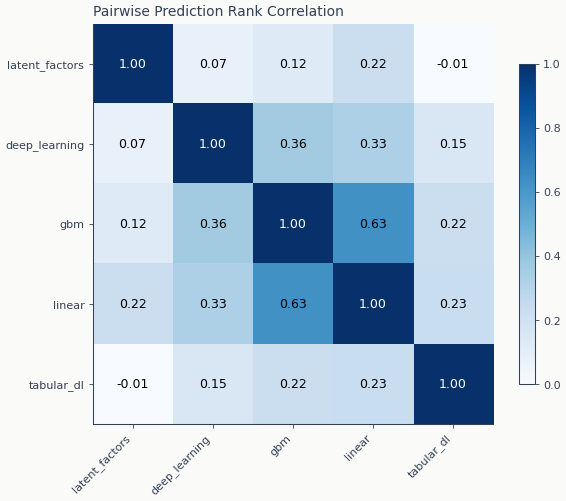

In [21]:
plot_correlation_matrix(corr_matrix, corr_labels)

The prediction correlation matrix reveals how much independent
information each family contributes. Pairs with correlation below 0.5
produce meaningfully different rankings and are candidates for
ensembling in Ch20. Pairs above 0.8 are essentially redundant —
the more complex model adds little over the simpler one.

Average pairwise correlation across the five families is 0.23
(range: −0.01 to 0.63). This relatively low average suggests that
most family pairs produce meaningfully different rankings. Families
with correlation below 0.5 are ensemble candidates in Ch20; pairs
above 0.8 are essentially redundant.

### How Much Does Additional Model Complexity Help?

For models with checkpoint data, we observe how validation IC evolves
with training. This reveals where diminishing returns begin and
whether models overfit with additional epochs.

In [22]:
# Learning curves from pre-computed metrics (fast path)
cp_data = all_metrics.filter(pl.col("checkpoint_value").is_not_null())
cp_families = (
    cp_data.group_by("family")
    .agg(pl.col("checkpoint_value").n_unique().alias("n_cp"))
    .filter(pl.col("n_cp") > 1)["family"]
    .to_list()
    if cp_data.height > 0
    else []
)

print(f"Families with checkpoint data: {cp_families}")

Families with checkpoint data: ['latent_factors', 'tabular_dl', 'deep_learning']


### Figure 6: Learning Curves

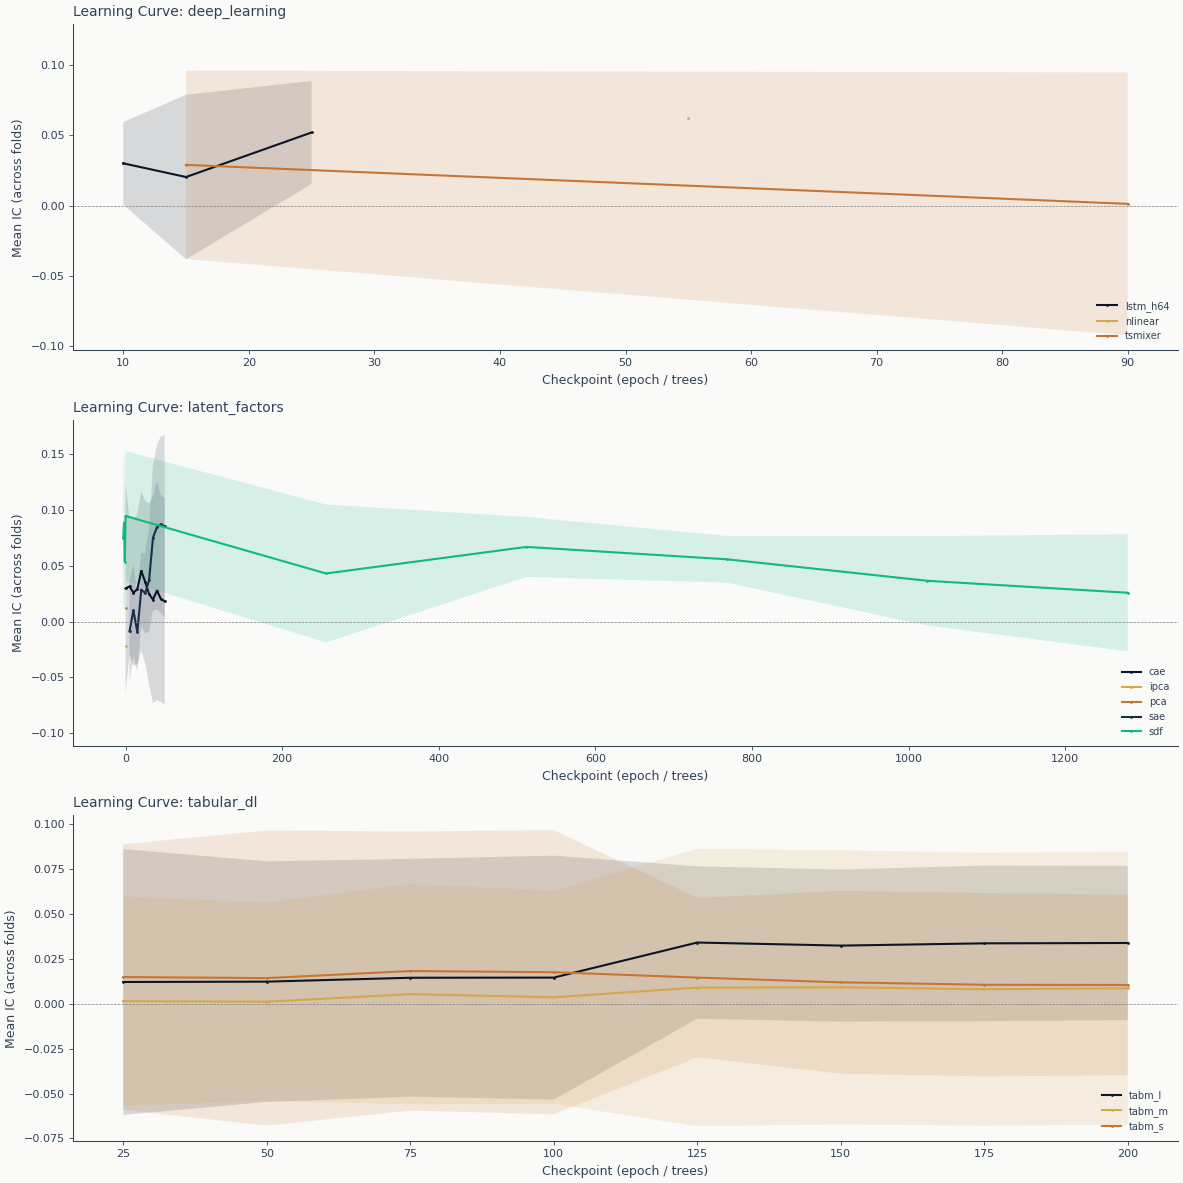

In [23]:
plot_learning_curves(cp_data, cp_families)

The learning curves (shown for the three families with multi-checkpoint
sweeps — deep learning, latent factors, tabular DL) reveal different
optimization dynamics:

- **Latent factors**: SDF (green) is the standout — its mean IC stays
  clearly positive across a long checkpoint range, peaking early
  ($\approx$ 0.095) and settling around 0.05–0.065, while the autoencoder
  and PCA/IPCA variants cluster at low checkpoints near zero. The long,
  stable positive band is the visual signature of the panel's strongest
  signal.
- **Deep learning**: the LSTM curve is non-monotonic — it dips then
  recovers to its best around checkpoint 25 — while TSMixer decays toward
  zero by its late checkpoints. The wide confidence bands echo the
  instability visible in the fold analysis, and are a reason the compact
  NLinear (a single well-chosen checkpoint) is the family's most reliable
  member.
- **Tabular DL**: only the larger TabM-L configuration climbs with
  training, plateauing around checkpoint 125; the smaller TabM-S/M
  variants stay near zero throughout, so capacity, not training length,
  is the binding constraint.

The practical takeaway: more training is not reliably better — each
family's best checkpoint is well short of its last, and the confidence
bands are wide enough that checkpoint choice within the plateau matters
little.

### Which Features Drive the Forecasts?

Feature importance from a single model fit is anecdotal. Recurring
importance across 8 walk-forward folds is evidence. We examine which
of the 57 momentum, volatility, and technical features consistently
drive the best model's predictions.

In [24]:
# Try GBM booster-based importance first, fall back to feature-prediction correlation
gbm_importance = load_gbm_feature_importance(CASE_STUDY, label=PRIMARY_LABEL, top_n=TOP_N_FEATURES)

if gbm_importance is None:
    # Fallback: compute feature-prediction IC (correlation between each feature and y_score)
    print("No GBM booster files available. Computing feature-prediction correlation as fallback...")

    features_path = CASE_DIR / "features" / "financial.parquet"
    if features_path.exists() and best_preds.height > 0:
        features_df = pl.read_parquet(features_path)
        feat_cols = [c for c in features_df.columns if c not in [DATE_COL, ENTITY_COL]]

        # Join best linear model predictions with features
        linear_preds = best_preds.filter(pl.col("family") == "linear")
        if linear_preds.height > 0:
            # Align timestamp types (predictions are Datetime; features may be Date or String)
            if features_df[DATE_COL].dtype == pl.String:
                features_df = features_df.with_columns(pl.col(DATE_COL).str.to_datetime())
            elif features_df[DATE_COL].dtype == pl.Date:
                features_df = features_df.with_columns(pl.col(DATE_COL).cast(pl.Datetime("ms")))
            merged = linear_preds.join(features_df, on=[DATE_COL, ENTITY_COL], how="inner")

            # Compute correlation of each feature with y_score per fold
            importance_rows = []
            for fold in sorted(merged["fold_id"].unique().drop_nulls().to_list()):
                fold_data = merged.filter(pl.col("fold_id") == fold)
                for feat in feat_cols:
                    vals = fold_data[[feat, "y_score"]].drop_nulls()
                    if vals.height > 50:
                        from scipy.stats import spearmanr

                        corr, _ = spearmanr(vals[feat].to_numpy(), vals["y_score"].to_numpy())
                        importance_rows.append(
                            {
                                "config_name": "linear",
                                "fold_id": int(fold),
                                "feature": feat,
                                "importance": abs(float(corr)),
                            }
                        )

            if importance_rows:
                gbm_importance = pl.DataFrame(importance_rows)
                # Normalize per fold
                gbm_importance = gbm_importance.with_columns(
                    (
                        pl.col("importance")
                        / pl.col("importance").max().over(["config_name", "fold_id"])
                    ).alias("importance_norm")
                )
                # Filter to top features
                top_features = (
                    gbm_importance.group_by("feature")
                    .agg(pl.col("importance_norm").mean().alias("mean_imp"))
                    .sort("mean_imp", descending=True)
                    .head(TOP_N_FEATURES)["feature"]
                    .to_list()
                )
                gbm_importance = gbm_importance.filter(pl.col("feature").is_in(top_features))
                print(
                    f"Computed feature-prediction correlation for {len(top_features)} features across {merged['fold_id'].n_unique()} folds"
                )

if gbm_importance is not None and gbm_importance.height > 0:
    print(
        f"Feature importance: {gbm_importance['feature'].n_unique()} features × {gbm_importance['fold_id'].n_unique()} folds"
    )
else:
    print("Feature importance data not available.")

Feature importance: 15 features × 8 folds


### Figure 7: Feature Importance Stability Heatmap


Persistent features (top-5 in ≥75% of folds): ['regime_log_duration']


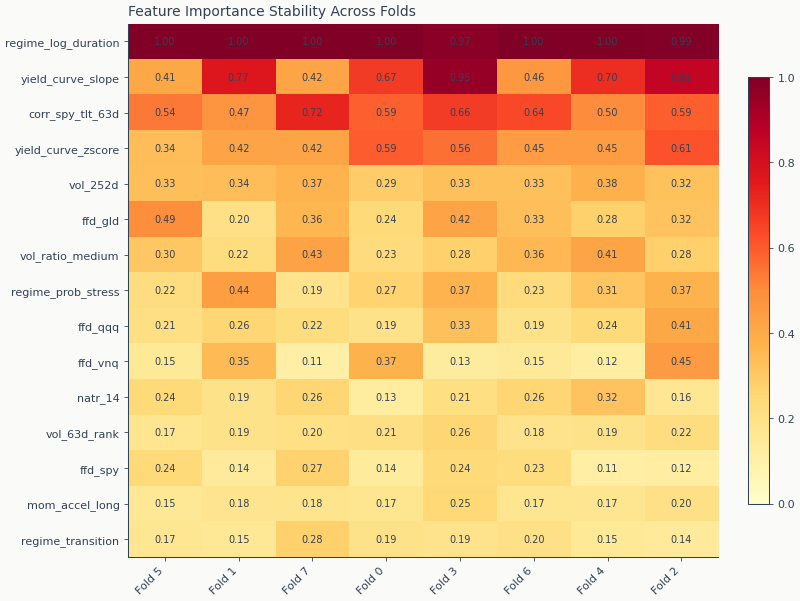

In [25]:
plot_feature_importance_heatmap(gbm_importance, TOP_N_FEATURES)

The feature importance heatmap uses the fallback method (feature-prediction
Spearman correlation) because stored GBM boosters lack named features.
Values are normalized to [0, 1] per fold. Features that appear in the
top 5 across 6+ of 8 folds are credible signal sources; those appearing
only once or twice likely capture regime-specific noise.

The 57 features span momentum (5d–252d), risk-adjusted momentum (Sharpe
ratios), volatility, technical indicators, and macro signals (yield curve
slope). The correlation-based importance reflects how strongly each
feature aligns with the linear model's predictions per fold.

## 6. Heterogeneity: Labels, Horizons, and Regimes

This section answers two questions: does the signal strengthen or
weaken at shorter horizons? And does model ranking depend on the
market regime? Both matter for strategy design.

### Multi-Label Comparison

Two horizons were trained: the primary `fwd_ret_21d` (monthly) and the
alternate `fwd_ret_5d` (weekly). The forest below renders the highest-IC
config per family for each horizon as a point estimate with the HAC 95%
CI. Tiles labeled "no run" mean a family was not trained on that label.
Comparing across the two panels diagnoses whether the cross-sectional
signal strengthens or weakens with horizon, and whether family ranking
is horizon-stable.

In [26]:
multi_rows = []
for lbl in [PRIMARY_LABEL] + [l for l in all_labels if l != PRIMARY_LABEL]:
    lbl_metrics = all_labels_metrics.filter(pl.col("label") == lbl)
    # Full-coverage guard (see forest_df above): exclude configs whose daily IC is
    # defined on only a subset of folds so a family's per-horizon leader is a
    # full-coverage estimator, not a partial-coverage outlier.
    _lbl_full = lbl_metrics["ic_n_days"].max()
    lbl_metrics = lbl_metrics.filter(pl.col("ic_n_days") == _lbl_full)
    for fam in lbl_metrics["family"].unique().to_list():
        fam_data = lbl_metrics.filter(pl.col("family") == fam)
        rank1 = fam_data.sort("ic_mean_daily", descending=True, nulls_last=True).head(1)
        if rank1.height == 0:
            continue
        r = rank1.row(0, named=True)
        if r.get("ic_mean_daily") is None:
            continue
        multi_rows.append(
            {
                "label": lbl,
                "family": fam,
                "config_name": r["config_name"],
                "ic_mean_daily": r["ic_mean_daily"],
                "ic_ci_lo": r.get("ic_ci_lo"),
                "ic_ci_hi": r.get("ic_ci_hi"),
                "ic_t_hac": r.get("ic_t_hac"),
            }
        )

multi_label_df = pl.DataFrame(multi_rows)
multi_label_df

label,family,config_name,ic_mean_daily,ic_ci_lo,ic_ci_hi,ic_t_hac
str,str,str,f64,f64,f64,f64
"""fwd_ret_21d""","""deep_learning""","""nlinear""",0.062197,0.021859,0.102535,3.023864
"""fwd_ret_21d""","""gbm""","""leaves_7_mae""",0.043997,0.006073,0.081921,2.275189
"""fwd_ret_21d""","""tabular_dl""","""tabm_l""",0.034087,-0.000296,0.06847,1.944256
"""fwd_ret_21d""","""linear""","""ridge_a1000000.0""",0.042013,-0.003379,0.087406,1.815144
"""fwd_ret_21d""","""latent_factors""","""sdf""",0.099206,0.065131,0.133281,5.709647
"""fwd_ret_5d""","""latent_factors""","""ipca""",0.009947,-0.011175,0.031069,0.923555
"""fwd_ret_5d""","""linear""","""ridge_a1000000.0""",0.029938,0.003243,0.056632,2.199424
"""fwd_ret_5d""","""gbm""","""leaves_15_mae""",0.029909,0.006036,0.053781,2.457015


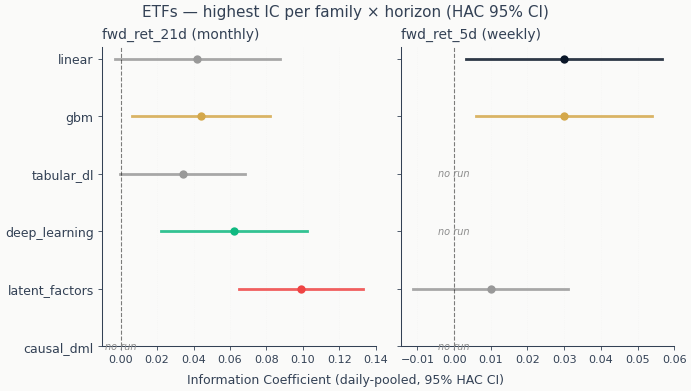

In [27]:
plot_label_horizon_forest(
    multi_label_df,
    families=["linear", "gbm", "tabular_dl", "deep_learning", "latent_factors", "causal_dml"],
    labels=[PRIMARY_LABEL] + [l for l in all_labels if l != PRIMARY_LABEL],
    label_display={
        "fwd_ret_21d": "fwd_ret_21d (monthly)",
        "fwd_ret_5d": "fwd_ret_5d (weekly)",
    },
    title="ETFs — highest IC per family × horizon (HAC 95% CI)",
)

Coverage is itself the first observation: the 21-day horizon has
runs for five families (linear, GBM, tabular_dl, deep_learning, latent
factors), while only three (linear, GBM, latent factors via IPCA) were
trained at the weekly horizon. Within the families that span both
panels, the absolute IC magnitudes are modest and the credibility
pattern is horizon-dependent. Linear (ridge $\alpha=10^6$) is actually
*more* credible at the weekly horizon (+0.030, CI excludes zero,
$t_{HAC}\approx 2.2$) than at the monthly horizon (+0.042, CI straddles
zero, $t_{HAC}\approx 1.8$) — the wider daily sample at 5 days tightens
the interval. GBM is credibly nonzero at *both* horizons (+0.044
monthly, +0.030 weekly, both CIs excluding zero), the only predictive
family that clears the bar at 5 days as well as 21 days. The IPCA
estimator is the only LF run at 5 days and is below credibility (+0.010,
CI brackets zero) there. The qualitative reading is that the monthly
window carries the strongest single signal (SDF, latent factors), while
the shorter weekly window is where the simpler linear and tree models
find their most *reliable*, if smaller, edge.

### Regime Conditioning

Models do not have one universal performance level. The ETF cross-section
is driven by macro regimes: risk-on/risk-off rotations, volatility spikes,
and trend reversals can all shift which model family extracts signal. We
condition performance on a volatility regime derived from cross-sectional
return dispersion — a natural proxy for macro uncertainty.

In [28]:
# Compute regime-conditional IC
regime_results = []

for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    regime_ic = regime_conditional_ic(model_preds, date_col=DATE_COL)
    if regime_ic.height > 0:
        regime_ic = regime_ic.with_columns(pl.lit(family).alias("family"))
        regime_results.append(regime_ic)

regime_df = pl.concat(regime_results) if regime_results else pl.DataFrame()

### Figure 8: Conditional Performance by Volatility Regime

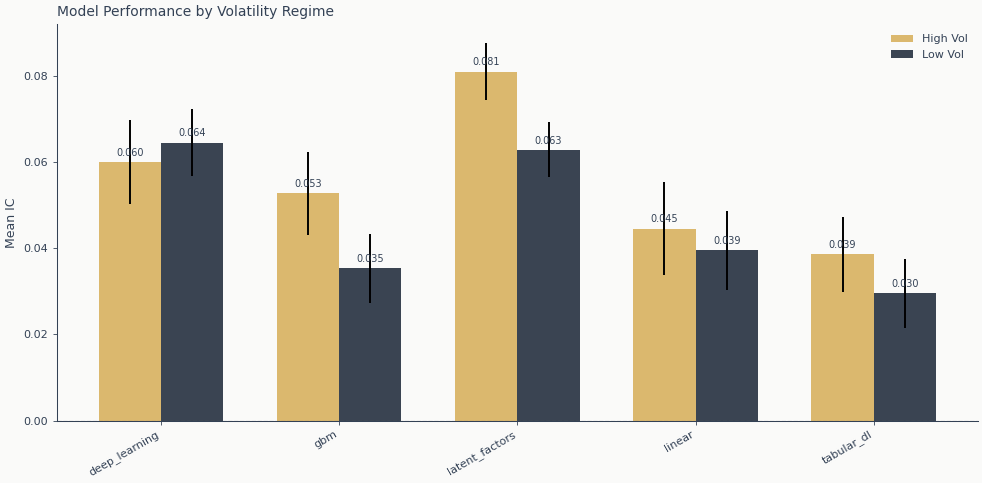

In [29]:
plot_regime_bars(regime_df)

Regime sensitivity is critical for ETF rotation strategies because the
universe itself is a macro instrument. During high-volatility periods
(risk-off), the cross-section separates more sharply — bonds rally
while commodities and emerging markets sell off — creating larger
cross-sectional spreads for models to exploit. During low-volatility
periods (risk-on), ETF returns converge, and cross-sectional
dispersion shrinks, making ranking harder.

If one model family achieves the highest IC in high-vol but fails in
low-vol, a regime-conditional strategy that switches models (or adjusts
position sizing) based on realized volatility may produce a higher
net IC than a static choice.

## 7. Structural and Causal Evidence

Not all model chapters produce comparable predictive scores. Ch14
(latent factors) extracts structure; Ch15 (causal DML) estimates
treatment effects. These require separate evidence blocks.

### Latent Factors (Ch14)

ETFs is one of the five case studies in scope for the latent-factor
pipeline. Five latent factor models were trained on the 100-ETF
cross-section: PCA, IPCA,
CAE, SDF, and SAE. The diagnostics below examine the internal
structure of these models using persisted fold extras.

In [30]:
# Load latent factor diagnostics
lf_models = ["pca", "ipca", "cae", "sdf", "sae"]
lf_extras = {m: load_fold_extras(CASE_STUDY, m) for m in lf_models}
lf_extras = {m: e for m, e in lf_extras.items() if e is not None}

# Print IC summary from registry
lf_metrics = all_labels_metrics.filter(
    pl.col("family") == "latent_factors", pl.col("label") == PRIMARY_LABEL
)
if lf_metrics.height > 0:
    lf_best = (
        lf_metrics.group_by("config_name")
        .agg(ic=pl.col("ic_mean").max())
        .sort("ic", descending=True)
    )
    print(f"Latent factor IC on {PRIMARY_LABEL}:")
    for row in lf_best.iter_rows(named=True):
        ic_text = f"{row['ic']:+.4f}" if row["ic"] is not None else "n/a"
        print(f"  {row['config_name']:6s}: {ic_text}")

print(f"\nFold extras available: {list(lf_extras.keys())}")

Latent factor IC on fwd_ret_21d:
  sdf   : +0.0944
  sae   : +0.0868
  cae   : +0.0452
  pca   : +0.0119
  ipca  : -0.0222

Fold extras available: ['pca', 'ipca', 'cae', 'sdf', 'sae']


#### PCA Variance Decomposition

The scree plot shows how much variance the first $K$ components capture.
A steep dropoff after 1-2 components indicates dominant market factors;
a flat profile suggests diffuse structure harder to exploit.

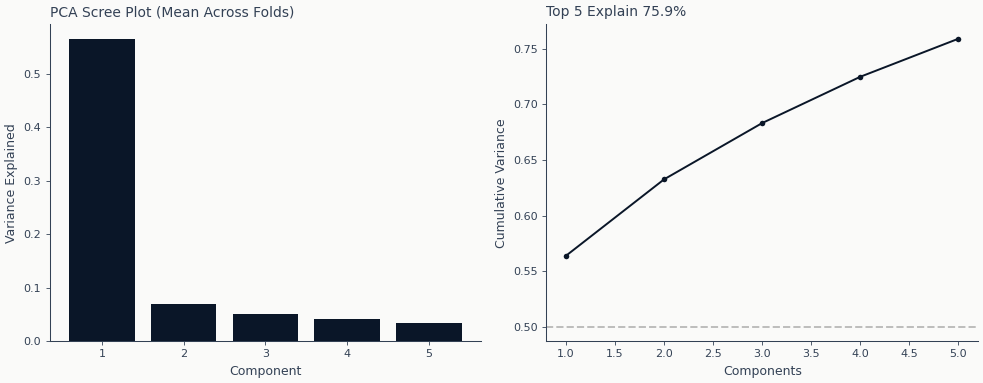

In [31]:
if "pca" in lf_extras:
    var_ratios = [e["explained_variance_ratio"] for e in lf_extras["pca"]]
    mean_var = np.mean(var_ratios, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].bar(range(1, len(mean_var) + 1), mean_var, color=COLORS["blue"])
    axes[0].set_xlabel("Component")
    axes[0].set_ylabel("Variance Explained")
    axes[0].set_title("PCA Scree Plot (Mean Across Folds)")

    axes[1].plot(range(1, len(mean_var) + 1), np.cumsum(mean_var), marker="o", color=COLORS["blue"])
    axes[1].set_xlabel("Components")
    axes[1].set_ylabel("Cumulative Variance")
    axes[1].set_title(f"Top {len(mean_var)} Explain {sum(mean_var):.1%}")
    axes[1].axhline(0.5, ls="--", color="gray", alpha=0.5)
    fig.tight_layout()
    fig.show()
else:
    print("PCA fold extras not available")

**Interpretation**: The scree plot characterizes the linear factor
decomposition of the ETF cross-section. Reading the latent-factor
highest-IC table from the registry, the ordering on the validation
panel is SDF +0.099 ($t_{HAC}=5.7$), SAE +0.064 ($t_{HAC}=3.3$),
CAE +0.046 ($t_{HAC}=2.1$, CI just clears zero), PCA +0.010
(CI straddles zero, $t_{HAC}\approx 0.4$), IPCA −0.013. The estimators
that produce credibly nonzero IC are SDF (pricing-kernel objective),
SAE (supervised autoencoder, which uses return labels during latent
extraction), and marginally CAE. The unsupervised *linear* methods
(PCA, IPCA) do not separate from zero on this panel — the 100-ETF
cross-section appears too small or too homogeneous for them to
identify stable, tradeable loadings, whereas the objective-driven
estimators (SDF, SAE) extract a clear signal.

#### CAE / SAE Training Convergence

Epoch loss curves reveal training dynamics: rapid initial descent
followed by a plateau indicates the model has converged. Divergent
curves across folds suggest instability.

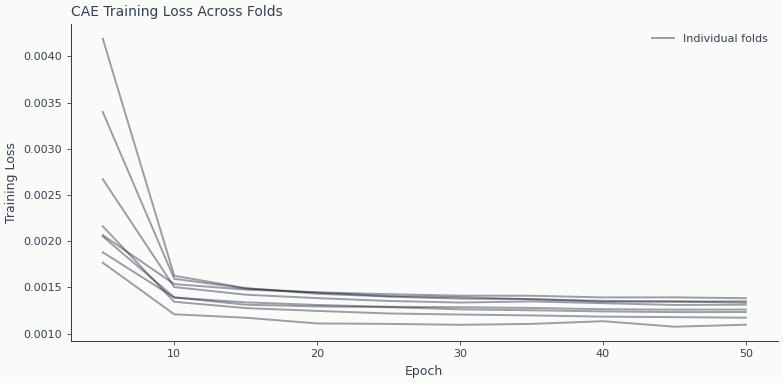

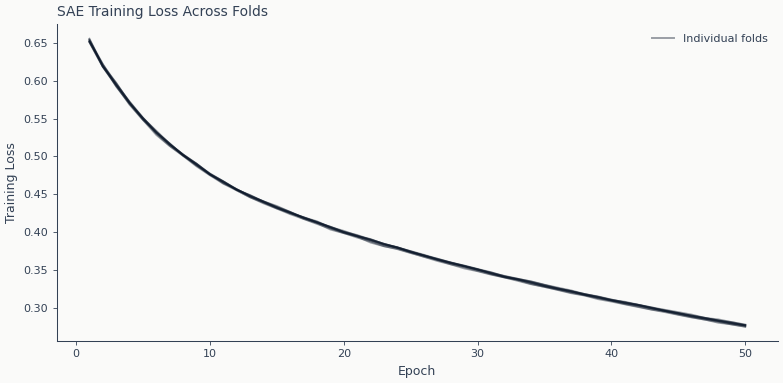

In [32]:
for model_name in ["cae", "sae"]:
    if model_name not in lf_extras:
        continue
    fig, ax = plt.subplots(figsize=(8, 4))
    plotted = False
    for i, fold in enumerate(lf_extras[model_name]):
        history = [h for h in fold.get("train_history", []) if "train_loss" in h]
        if history:
            epochs = [h["epoch"] for h in history]
            vals = [h["train_loss"] for h in history]
            ax.plot(
                epochs,
                vals,
                alpha=0.4,
                color=COLORS["blue"],
                label="Individual folds" if not plotted else None,
            )
            plotted = True
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    ax.set_title(f"{model_name.upper()} Training Loss Across Folds")
    if plotted:
        ax.legend(loc="upper right")
    fig.tight_layout()
    fig.show()

**Interpretation**: The convergence curves above show whether CAE and
SAE training stabilized. Consistent convergence across folds indicates
the autoencoder captures reproducible structure; divergent curves
suggest the latent representation is fold-dependent and less reliable
for downstream prediction.

#### SDF Sharpe Ratios

The SDF model's internal sharpe ratio measures the pricing kernel's
ability to span the space of tradeable portfolios. Higher sharpe
indicates stronger no-arbitrage constraints.

In [33]:
if "sdf" in lf_extras:
    sharpes = [e.get("sdf_sharpe", None) for e in lf_extras["sdf"]]
    sharpes = [s for s in sharpes if s is not None]
    if sharpes:
        print(f"SDF Sharpe across folds: mean={np.mean(sharpes):.3f}, std={np.std(sharpes):.3f}")
        print(f"  Range: [{min(sharpes):.3f}, {max(sharpes):.3f}]")
else:
    print("SDF fold extras not available")

SDF Sharpe across folds: mean=0.591, std=0.055
  Range: [0.505, 0.670]


**Interpretation**: SDF achieves daily-pooled validation IC
$\approx$ +0.099 with the strongest HAC t-statistic not just in the
latent-factor family but across all families ($t_{HAC} \approx 5.7$).
The internal Sharpe values reported above (mean $\approx$ 0.59 across
folds) describe the pricing kernel's ability to span tradeable
portfolios; combined with the leading IC, SDF is the strongest signal
on the 100-ETF panel, ahead of SAE and the predictive families.

### Causal DML (Ch15)

In [34]:
# Load causal DML evidence. Ch15 writes to the ``causal_runs`` registry table
# (double-ML treatment-effect estimates), not to ``prediction_metrics``, so it is
# queried separately from the predictive families above.
import sqlite3

from case_studies.utils.analytics import _registry_path

_cdb = _registry_path(CASE_STUDY)
with sqlite3.connect(str(_cdb)) as _cconn:
    _cconn.row_factory = sqlite3.Row
    _crows = [
        dict(r)
        for r in _cconn.execute(
            "SELECT treatment, dml_effect, dml_se_hac, p_value_hac, naive_effect, "
            "confounding_bias_pct, refutation_p FROM causal_runs WHERE label = ?",
            (PRIMARY_LABEL,),
        ).fetchall()
    ]

if _crows:
    cr = _crows[0]
    print(f"Causal DML on {PRIMARY_LABEL} (treatment = {cr['treatment']}):")
    print(
        f"  DML effect (ATE): {cr['dml_effect']:+.4f}  "
        f"(HAC SE {cr['dml_se_hac']:.4f}, p = {cr['p_value_hac']:.1e})"
    )
    print(
        f"  Naive (unadjusted) effect: {cr['naive_effect']:+.4f}  ->  "
        f"confounding bias {cr['confounding_bias_pct']:+.0f}%"
    )
    print(f"  Refutation p-value (placebo treatment): {cr['refutation_p']:.2f}")
    print("  Note: the ATE is the causal effect of the momentum treatment on forward")
    print("        returns; cross-sectional ranking ability is a separate question,")
    print("        documented by the predictive families above and in 12_causal_dml.")
else:
    print("No causal DML results available for this case study")

Causal DML on fwd_ret_21d (treatment = skip_recent_6_1):
  DML effect (ATE): -0.0578  (HAC SE 0.0059, p = 0.0e+00)
  Naive (unadjusted) effect: -0.0386  ->  confounding bias +33%
  Refutation p-value (placebo treatment): 0.00
  Note: the ATE is the causal effect of the momentum treatment on forward
        returns; cross-sectional ranking ability is a separate question,
        documented by the predictive families above and in 12_causal_dml.


Causal DML estimates the effect of the momentum treatment
(`skip_recent_6_1`) on forward returns after orthogonalizing
confounders (volatility, regime, yield-curve slope). The result is
nuanced: the **ATE is −0.058** (highly significant, p ≈ 0), meaning
higher momentum causes *lower* forward returns after controlling for
confounders — a mean-reversion effect, not momentum continuation.
Controlling for confounders *strengthens* the negative effect relative
to the naive estimate (−0.039), a confounding bias of roughly +33%, and
the effect survives a placebo-treatment refutation test.

This directional finding sits alongside the positive cross-sectional
ranking IC the predictive families deliver above: the supervised models
(ridge, GBM, TabM) exploit momentum as a *ranking* feature, not as a
directional bet. The causal evidence says the directional relationship
is contrarian (mean-reversion), while cross-sectional ranking ability is
positive. For a long-short strategy that cares only about relative
ranking, positive IC is what matters — but the negative ATE warns
against interpreting the momentum signal as "momentum continuation";
the mechanism is more likely mean-reversion in overbought/oversold ETFs.

### Calibration: Are Prediction Intervals Honest?

Point IC tells us whether the ranking is correct on average; it says
nothing about whether the model's *uncertainty* is well calibrated.
Inductive split-conformal prediction (Vovk et al., 2005; Lei et al.,
2018) gives a distribution-free check: using fold-0 absolute residuals
as a calibration set, the symmetric quantile $\hat{q}_{1-\alpha}$
defines an interval $[\hat{y} - \hat{q}, \hat{y} + \hat{q}]$ that
should cover the true label at rate $1-\alpha$ on the remaining folds.
Empirical coverage materially below the nominal level signals
overconfident residual scaling — the model is more wrong, more often,
than its training-time spread suggests. Width is reported as a
fraction of the actuals' standard deviation so families with different
return scales are comparable; smaller width at matched coverage means
tighter, more useful intervals. See Ch12 §12.6 / `11_conformal_gbm`
for the full conformal toolkit (CQR, ACI). What we report here is the
minimal residual-calibration diagnostic.

In [35]:
conformal_etfs = conformal_coverage_diagnostic(
    CASE_STUDY,
    label=PRIMARY_LABEL,
)
conformal_etfs

family,config_name,nominal_level,empirical_coverage,mean_interval_width_frac_std,n_test
str,str,f64,f64,f64,i64
"""deep_learning""","""nlinear""",0.8,0.751758,2.023834,165564
"""deep_learning""","""nlinear""",0.9,0.865067,2.736503,165564
"""deep_learning""","""nlinear""",0.95,0.923625,3.48331,165564
"""gbm""","""leaves_7_mae""",0.8,0.792314,2.004039,166044
"""gbm""","""leaves_7_mae""",0.9,0.873919,2.686028,166044
…,…,…,…,…,…
"""linear""","""enet_f0.85""",0.9,0.871901,2.652178,166044
"""linear""","""enet_f0.85""",0.95,0.921515,3.347366,166044
"""tabular_dl""","""tabm_l""",0.8,0.82006,2.568074,166044


In [36]:
if conformal_etfs.height > 0:
    pivot = conformal_etfs.pivot(
        on="nominal_level",
        index=["family", "config_name"],
        values=["empirical_coverage", "mean_interval_width_frac_std"],
    )
    print("Empirical coverage and width (× std of returns) at 80/90/95% nominal:")
    print(pivot)

Empirical coverage and width (× std of returns) at 80/90/95% nominal:
shape: (5, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ family     ┆ config_nam ┆ empirical_ ┆ empirical ┆ empirical ┆ mean_inte ┆ mean_inte ┆ mean_inte │
│ ---        ┆ e          ┆ coverage_0 ┆ _coverage ┆ _coverage ┆ rval_widt ┆ rval_widt ┆ rval_widt │
│ str        ┆ ---        ┆ .8         ┆ _0.9      ┆ _0.95     ┆ h_frac_st ┆ h_frac_st ┆ h_frac_st │
│            ┆ str        ┆ ---        ┆ ---       ┆ ---       ┆ d_0…      ┆ d_0…      ┆ d_0…      │
│            ┆            ┆ f64        ┆ f64       ┆ f64       ┆ ---       ┆ ---       ┆ ---       │
│            ┆            ┆            ┆           ┆           ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ deep_learn ┆ nlinear    ┆ 0.751758   ┆ 0.865067  ┆ 0.923625  ┆ 2.023834  ┆ 2.736503  ┆ 3.48331   │
│ ing  

Coverage at the three nominal levels tracks the targets reasonably
closely across families, with most highest-IC configs landing within a few
percentage points of nominal. Departures are informative: under-coverage
(empirical < nominal) signals residuals heavier-tailed than the
calibration window suggests — a known concern for daily ETF returns
with episodic volatility shocks; over-coverage means intervals are
wider than needed. Width-per-std is the more useful axis for
distinguishing models: at matched coverage, a family whose intervals
are narrower in std-units is producing tighter forecasts of the
residual distribution. This calibration diagnostic feeds Ch19 risk
management — wider intervals naturally scale down position size, and
ACI extensions (Ch12 §12.6) update interval width online to track
regime shifts in residual variance.

## 8. Pre-Backtest Judgment and Handoff

This section assembles the empirical record this analysis can speak to,
and names what it cannot. The Ch16 selection workflow then picks the
top candidate from the signal-stage backtest and retrains it on the
holdout window — the val→holdout decay is the most honest generalization
evidence we have.

In [37]:
# Validation IC summary (per-family highest-IC config, daily-pooled with HAC CI)
print("Validation IC summary — daily-pooled with HAC 95% CI:")
print(
    forest_df.select(
        "family",
        "config_name",
        pl.col("ic_mean_daily").round(4).alias("ic"),
        pl.col("ic_ci_lo").round(4).alias("ci_lo"),
        pl.col("ic_ci_hi").round(4).alias("ci_hi"),
        pl.col("ic_t_hac").round(2).alias("t_hac"),
    )
)

Validation IC summary — daily-pooled with HAC 95% CI:
shape: (5, 6)
┌────────────────┬──────────────────┬────────┬─────────┬────────┬───────┐
│ family         ┆ config_name      ┆ ic     ┆ ci_lo   ┆ ci_hi  ┆ t_hac │
│ ---            ┆ ---              ┆ ---    ┆ ---     ┆ ---    ┆ ---   │
│ str            ┆ str              ┆ f64    ┆ f64     ┆ f64    ┆ f64   │
╞════════════════╪══════════════════╪════════╪═════════╪════════╪═══════╡
│ latent_factors ┆ sdf              ┆ 0.0992 ┆ 0.0651  ┆ 0.1333 ┆ 5.71  │
│ deep_learning  ┆ nlinear          ┆ 0.0622 ┆ 0.0219  ┆ 0.1025 ┆ 3.02  │
│ gbm            ┆ leaves_7_mae     ┆ 0.044  ┆ 0.0061  ┆ 0.0819 ┆ 2.28  │
│ linear         ┆ ridge_a1000000.0 ┆ 0.042  ┆ -0.0034 ┆ 0.0874 ┆ 1.82  │
│ tabular_dl     ┆ tabm_l           ┆ 0.0341 ┆ -0.0003 ┆ 0.0685 ┆ 1.94  │
└────────────────┴──────────────────┴────────┴─────────┴────────┴───────┘


In [38]:
# Selection-adjusted leader table at the signal stage. Pulls DSR /
# expected-max-Sharpe / Reality-Check p-value / PBO / k_variants from
# the ``cohort_metrics`` table — these encode the cost of having tried
# many configs before declaring a top candidate. ``dsr`` is the
# effective-rank (ER) deflated Sharpe (the library default); the row
# also exposes ``dsr_mp`` and ``dsr_raw`` for sensitivity.
sel_adj = selection_adjusted_leader_table(CASE_STUDY, stage="signal")
print("\nSelection-adjusted signal-stage leader per family:")
print(
    sel_adj.select(
        "family",
        "config_name",
        pl.col("sharpe").round(3),
        pl.col("sharpe_ci95_lo").round(3).alias("sh_lo"),
        pl.col("sharpe_ci95_hi").round(3).alias("sh_hi"),
        pl.col("dsr").round(3),
        pl.col("expected_max_sharpe").round(3).alias("exp_max"),
        pl.col("reality_check_pvalue").round(3).alias("rc_p"),
        pl.col("pbo").round(2),
        pl.col("k_variants").cast(pl.Int64).alias("k"),
    )
)


Selection-adjusted signal-stage leader per family:
shape: (5, 10)
┌────────────────┬───────────────┬────────┬───────┬───┬─────────┬──────┬──────┬─────┐
│ family         ┆ config_name   ┆ sharpe ┆ sh_lo ┆ … ┆ exp_max ┆ rc_p ┆ pbo  ┆ k   │
│ ---            ┆ ---           ┆ ---    ┆ ---   ┆   ┆ ---     ┆ ---  ┆ ---  ┆ --- │
│ str            ┆ str           ┆ f64    ┆ f64   ┆   ┆ f64     ┆ f64  ┆ f64  ┆ i64 │
╞════════════════╪═══════════════╪════════╪═══════╪═══╪═════════╪══════╪══════╪═════╡
│ latent_factors ┆ pca           ┆ 0.915  ┆ 0.23  ┆ … ┆ 0.006   ┆ null ┆ 0.34 ┆ 78  │
│ deep_learning  ┆ lstm_h64      ┆ 0.888  ┆ 0.333 ┆ … ┆ 0.006   ┆ null ┆ 0.77 ┆ 20  │
│ linear         ┆ enet_a0.01    ┆ 0.77   ┆ 0.167 ┆ … ┆ 0.001   ┆ null ┆ 0.34 ┆ 56  │
│ tabular_dl     ┆ tabm_l        ┆ 0.754  ┆ 0.013 ┆ … ┆ 0.001   ┆ null ┆ 0.8  ┆ 52  │
│ gbm            ┆ leaves_15_mse ┆ 0.738  ┆ 0.028 ┆ … ┆ 0.002   ┆ null ┆ 0.26 ┆ 34  │
└────────────────┴───────────────┴────────┴───────┴───┴─────────┴──────┴─

In [39]:
# Holdout decay for the top candidate. By design (Ch16 selection
# workflow) only the signal-stage top family is retrained on the
# holdout window — other families show null on the holdout side
# because they were never selected for retraining.
decay = holdout_decay_table(CASE_STUDY, label=PRIMARY_LABEL)
print("\nHoldout decay (top family only — others were not selected for retrain):")
print(
    decay.select(
        "family",
        "config_name",
        pl.col("val_ic").round(4),
        pl.col("val_ci_lo").round(4).alias("val_lo"),
        pl.col("val_ci_hi").round(4).alias("val_hi"),
        pl.col("ho_ic").round(4),
        pl.col("ho_ci_lo").round(4).alias("ho_lo"),
        pl.col("ho_ci_hi").round(4).alias("ho_hi"),
        pl.col("decay_pp").round(4).alias("decay"),
    )
)


Holdout decay (top family only — others were not selected for retrain):
shape: (5, 9)
┌────────────────┬──────────────┬────────┬─────────┬───┬─────────┬─────────┬───────┬────────┐
│ family         ┆ config_name  ┆ val_ic ┆ val_lo  ┆ … ┆ ho_ic   ┆ ho_lo   ┆ ho_hi ┆ decay  │
│ ---            ┆ ---          ┆ ---    ┆ ---     ┆   ┆ ---     ┆ ---     ┆ ---   ┆ ---    │
│ str            ┆ str          ┆ f64    ┆ f64     ┆   ┆ f64     ┆ f64     ┆ f64   ┆ f64    │
╞════════════════╪══════════════╪════════╪═════════╪═══╪═════════╪═════════╪═══════╪════════╡
│ latent_factors ┆ sdf          ┆ 0.0992 ┆ 0.0651  ┆ … ┆ null    ┆ null    ┆ null  ┆ null   │
│ linear         ┆ enet_f0.85   ┆ 0.0544 ┆ -0.0025 ┆ … ┆ null    ┆ null    ┆ null  ┆ null   │
│ deep_learning  ┆ lstm_h64     ┆ 0.0521 ┆ 0.0091  ┆ … ┆ -0.0319 ┆ -0.0847 ┆ 0.021 ┆ -0.084 │
│ gbm            ┆ leaves_7_mae ┆ 0.044  ┆ 0.0061  ┆ … ┆ null    ┆ null    ┆ null  ┆ null   │
│ tabular_dl     ┆ tabm_l       ┆ 0.0341 ┆ -0.0003 ┆ … ┆ null    ┆ 

### What the empirical record says

**The validation top cluster.** SDF leads clearly at IC $\approx$ 0.099
with a HAC 95% CI that excludes zero by a wide margin ($t_{HAC} \approx
5.7$), NLinear follows at $\approx$ 0.062 ($t_{HAC} \approx 3.0$), and
GBM at $\approx$ 0.044 has a CI whose lower bound just clears zero
($t_{HAC} \approx 2.3$). The linear leader (ridge $\alpha=10^6$) at
$\approx$ 0.042 and TabM-L at $\approx$ 0.034 have CIs that straddle
zero ($t_{HAC} \approx 1.8$ and 1.9). The collective claim the
validation set supports is that cross-sectional predictability at the
21-day horizon is real on this panel for the post-2010 era, carried
mainly by SDF with progressively weaker evidence as the table descends.

**Below the leader, the cluster is wide.** SDF aside, the CI overlap
across the remaining families is heavy — NLinear, GBM, ridge, and
TabM-L are not statistically separated from one another. This is a
signal about the case study, not about the models: below the SDF
signal, the ETF cross-section at this horizon is bounded in how much
daily-pooled IC any reasonable predictor can extract.

**The selection-adjusted leader is not the validation IC leader.**
Validation IC ranks SDF first; the signal-stage backtest's selection-
adjusted Sharpe ranks a PCA configuration first within latent factors
(Sharpe $\approx$ 0.92) and an LSTM configuration a close second within
deep learning (Sharpe $\approx$ 0.89), with linear (Sharpe $\approx$
0.77), TabM-L ($\approx$ 0.75), and GBM ($\approx$ 0.74) behind. The IC
ordering and the Sharpe ordering disagree because IC is a rank-
correlation metric while Sharpe encodes execution costs, turnover, and
the discrete portfolio construction the backtest applies. Whichever
family the signal-stage backtest names as the leader has already paid
the multiple-comparisons penalty implicitly via the selection process;
the table above makes the penalty (DSR, expected-max-Sharpe, PBO)
visible.

**Holdout evidence is partial — and sobering.** Only the signal-stage
top candidate is retrained on the holdout window (the Ch16 / Ch20
selection workflow), so the decay table populates a single row. For the
ETFs case study the holdout retrain ran for the LSTM top candidate: its
validation daily-pooled IC of +0.052 decays to a *negative* holdout IC
of −0.032 (a −0.084 swing, with the holdout-side HAC CI spanning zero).
One year of monthly holdout is a small sample, so this is a wide
estimate, but the sign flip is a genuine caution — the signal that
looked strongest through selection does not carry cleanly into
2024–2025. The cleanest generalization evidence comes from the
strategy-side notebook (`18_strategy_analysis.py`) and the Ch20 holdout
summary.

### Forecast representation downstream

For backtesting, predictions are used as:

- **Rank-based selection**: sort by `y_score`, select top-N ETFs
- **Score weighting**: use `y_score` magnitudes for position sizing
- **Ensemble**: pairwise correlation $< 0.7$ is the threshold for
  ensembling, applied in Ch20 across families that survive the
  signal-stage backtest

### What this analysis does NOT tell us

- **Net-of-cost edge**: bucket spreads must survive round-trip
  costs of 10–30 bps. The signal-stage backtest in `14_backtest.py`
  tests this directly; this notebook only speaks to gross IC.
- **Survivorship**: the 100-ETF universe was selected
  backward-looking (see `setup.yaml` eligibility note). A
  forward-living universe may degrade further than the holdout
  decay suggests.
- **Regime stationarity**: 2024-onwards holdout covers $\approx$
  one year of monthly rebalancing — the decay number is itself
  an estimate with non-trivial standard error.
- **Inter-family ranking outside this CV split**: the validation
  leader was determined on this specific 8-fold rolling-window
  protocol. Re-running with different fold boundaries would shift
  the leader within the top cluster.

**Next**: `14_backtest.py` for strategy simulation,
`15_portfolio_management.py` for position sizing,
`18_strategy_analysis.py` for the strategy-side counterpart of
this analysis, and `20_synthesis.py` for end-to-end results.

## Key Takeaways

1. **One clear signal, then a modest tail**: SDF leads at IC $\approx$
   0.099 with a HAC CI that clears zero decisively ($t_{HAC} \approx
   5.7$) — the strongest signal on the panel. NLinear ($\approx$ 0.062)
   and GBM ($\approx$ 0.044) also clear zero; the linear and tabular
   leaders do not. This is weak by single-stock standards but, for SDF,
   persistent across a multi-asset cross-section over the post-2010 era.
2. **Below SDF, CI overlap is the central caveat**: NLinear, GBM,
   ridge, and TabM-L overlap heavily in their 95% HAC CIs. Treating any
   of them as separable from the others on validation IC alone
   overstates what the data supports — only SDF stands clearly apart.
3. **Selection-adjusted statistics shift the choice**: validation IC
   ranks SDF first, but the signal-stage backtest's selection-adjusted
   Sharpe ranks a PCA configuration first (with an LSTM config a close
   second). IC measures rank correlation; Sharpe encodes execution
   costs, turnover, and discrete portfolio construction. The two leaders
   need not coincide, and `expected_max_sharpe` / DSR / PBO make the
   multiple-comparisons penalty explicit.
4. **Latent-factor methods, fine-grained reading**: SDF and SAE produce
   credibly nonzero IC on this panel ($t_{HAC}$ of 5.7 and 3.3), and CAE
   marginally clears zero ($t_{HAC} \approx 2.1$); PCA and IPCA have CIs
   that straddle zero. ETFs qualifies as a latent-factor case study by
   panel dimensionality, and the objective-driven estimators (SDF, SAE)
   are where its signal concentrates.
5. **Causal DML adds nuance, not a directional bet**: the ATE is
   contrarian (mean-reversion, $\approx -0.058$, p ≈ 0) while the
   predictive families' ranking IC is positive, underlining that ranking
   ability and directional causation are different questions here.
6. **Holdout evidence is partial and sobering**: the val→holdout decay
   row populates only the retrained LSTM winner, whose validation IC of
   +0.052 flips to a *negative* holdout IC of −0.032 (−0.084 swing) on
   the one-year 2024–2025 window. The sample is small, but the sign flip
   tempers the in-sample ranking. The cleanest out-of-sample signal
   comes from the strategy-side notebook (`18_strategy_analysis.py`) and
   the Ch20 holdout summary, which operate on the actual retrained
   predictions.

**Next**: `14_backtest.py` applies these predictions to simulated trading.